<a href="https://colab.research.google.com/github/jacielefreitas63-tech/projeto-delivery-logistic/blob/main/1_limpeza_e_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Projeto Delivery: Engenharia de Dados & Análise Exploratória (EDA)


 # 1 Configuração do Ambiente e Conexão com o Data Lake (Google Drive)

Neste notebook, realizaremos a ingestão, limpeza fina, tratamento de outliers e união das bases transacionais da *Olist, malha rodoviária do **OpenStreetMap* e dados meteorológicos do *INMET*.

In [ ]:
!pip install osmnx networkx pandas numpy pyspark

In [ ]:
# Importação das bibliotecas fundamentais para manipulação e análise estatística
import pandas as pd
import numpy as np
import networkx as nx
import osmnx as ox

# Imports específicos do PySpark para processamento distribuído
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
print("🚀 Bibliotecas carregadas com sucesso!")

🚀 Bibliotecas carregadas com sucesso!


In [ ]:
# Inicialização do motor do Spark
spark = SparkSession.builder \
    .appName("LogisticaDelivery") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("🚀 Spark inicializado com sucesso e pronto para processamento distribuído!")

🚀 Spark inicializado com sucesso e pronto para processamento distribuído!


In [ ]:
# Conexão segura com o armazenamento de dados do Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📦2.Ingestão da Base de Pedidos (Olist Orders)
> O objetivo desta etapa é ler o dataset transacional de ordens de serviço, inspecionar os tipos de dados primitivos e mapear o volume inicial de registros antes de aplicar as regras de limpeza.

In [ ]:
#Ingestão da Base de Pedidos (Olist Orders)

# Definir o caminho do arquivo
caminho_orders = "/content/drive/MyDrive/projeto_delivery_logistica/data/olist_orders_dataset.csv"

# --- BLOCO DE VALIDAÇÃO (Opcional, mas dá o ar profissional) ---
import os
if not os.path.exists(caminho_orders):
    raise FileNotFoundError(f"⚠️ Atenção: O arquivo não foi encontrado em: {caminho_orders}. Verifique se o caminho no Drive está correto.")
else:
    print("✅ Arquivo localizado com sucesso!")
# -------------------------------------------------------------

# Carregar o arquivo usando Pandas
df_orders = pd.read_csv(caminho_orders)

✅ Arquivo localizado com sucesso!


In [ ]:
# Verificar os tipos de dados de cada coluna e a presença de valores nulos
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


## 🛠️ 2. Conversão de Tipos (Cast) e Tratamento de Datas
> As colunas temporais de carimbo de data/hora (timestamps) precisam ser convertidas de object para datetime64. Isso nos permitirá calcular intervalos de tempo, como o tempo de entrega real (SLA) e atrasos.

In [ ]:
# Lista de colunas que contêm datas no dataset
colunas_datas = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Converter todas as colunas da lista para o formato datetime
for coluna in colunas_datas:
    df_orders[coluna] = pd.to_datetime(df_orders[coluna])

# Validar se a conversão funcionou checando os novos tipos
df_orders[colunas_datas].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


## 🔍 3. Análise de Valores Ausentes (Missing Values)
> Antes de qualquer modelagem preditiva, mapeamos o volume absoluto e percentual de nulos para decidir entre estratégias de imputação ou remoção de registros.

In [ ]:
# Calcular o total de nulos por coluna
total_nulos = df_orders.isnull().sum()

# Calcular a porcentagem de nulos por coluna
porcentagem_nulos = (df_orders.isnull().sum() / len(df_orders)) * 100

# Juntar as informações em um DataFrame de diagnóstico para o relatório
diagnostico_nulos = pd.DataFrame({'Total Nulos': total_nulos, 'Porcentagem (%)': porcentagem_nulos})
diagnostico_nulos.sort_values(by='Total Nulos', ascending=False)

,Total Nulos,Porcentagem (%)
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899
order_id,0,0.000000
order_purchase_timestamp,0,0.000000
order_status,0,0.000000
customer_id,0,0.000000
order_estimated_delivery_date,0,0.000000


## 🚚 4. Engenharia de Atributos (Feature Engineering): Métricas de SLA
> Criaremos as variáveis preditivas e de performance logística:
> 1. **tempo_entrega_dias**: Tempo real gasto desde a compra até a chegada ao cliente.
> 2. **atraso_entrega_dias**: Dias de atraso caso a entrega passe do prazo estimado (valores positivos indicam quebra de SLA).

In [ ]:
# 1. Calcular o tempo de entrega real em dias
df_orders['tempo_entrega_dias'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.total_seconds() / 86400

# 2. Calcular o atraso em relação à estimativa (Valores > 0 significam atraso)
df_orders['atraso_entrega_dias'] = (df_orders['order_delivered_customer_date'] - df_orders['order_estimated_delivery_date']).dt.total_seconds() / 86400

# Substituir valores negativos por 0 no atraso (pois entregas antes do prazo não têm atraso)
df_orders['atraso_entrega_dias'] = df_orders['atraso_entrega_dias'].clip(lower=0)

# Exibir uma amostragem com as novas colunas calculadas
df_orders[['order_id', 'tempo_entrega_dias', 'atraso_entrega_dias']].head()

,order_id,tempo_entrega_dias,atraso_entrega_dias
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,0.0


## 🌤️ 5. Ingestão e Tratamento de Dados Meteorológicos (INMET)
> O objetivo desta etapa é carregar o histórico climático, tratar valores nulos de precipitação (chuva) e preparar a base para cruzamento temporal com os momentos de compra e entrega.

In [ ]:
# Mapear o caminho correto com o nome do arquivo da região Sudeste
# O PySpark é otimizado para não estourar a RAM
caminho_clima = "/content/drive/MyDrive/projeto_delivery_logistica/data/southeast.csv"

# Usando o leitor do PySpark
df_clima = spark.read.csv(caminho_clima, header=True, inferSchema=True)

# Agora, o filtro de SP (que você já tinha) funcionará sem travar a memória
df_sp = df_clima.filter(df_clima['state'] == 'SP')

print("✅ Dados carregados via PySpark. Memória preservada!")
df_sp.show(5)

✅ Dados carregados via PySpark. Memória preservada!
+-----+----------+-------------------+--------------------------------+-----------------------------------------------------+-----------------------------------------------+------------------------------------------------+-----------------------+--------------------------------------------+------------------------------------+------------------------------------------+------------------------------------------+------------------------------------------------+------------------------------------------------+----------------------------------------+----------------------------------------+-----------------------------------+------------------------------------+--------------------------+-------------------------------+------+-----+-------+------------+------------+------------+------+
|index|      Data|               Hora|PRECIPITAÇÃO TOTAL, HORÁRIO (mm)|PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)|PRESSÃO ATMOSFERICA MAX.NA HO

In [ ]:
from pyspark.sql.functions import col, when

# Tratamento profissional dos dados climáticos
# 1. Substitui -9999 por NULL (None) para o Spark entender que são dados faltantes
# 2. Preenche os NULLs com 0 (assumindo que ausência de leitura = sem chuva relevante)
df_clima_limpo = df_clima.withColumn(
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)", # Use o nome da coluna original aqui
    when(col("PRECIPITAÇÃO TOTAL, HORÁRIO (mm)") == -9999, 0).otherwise(col("PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"))
).fillna({"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": 0})

In [ ]:
# --- Célula corrigida para PySpark ---
from pyspark.sql import functions as F

# 1. Filtrar o dataset para SP (Já feito, mas mantendo a lógica)
df_clima_sp = df_sp  # df_sp já é o seu dataframe filtrado

# 2. Substituir os códigos de erro (-9999.0 e 9999.0) por null
# No Spark, usamos .when().otherwise()
colunas_numericas = [
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)' # Nome corrigido da coluna
]

for col in colunas_numericas:
    df_clima_sp = df_clima_sp.withColumn(col,
        F.when((F.col(col) == -9999.0) | (F.col(col) == 9999.0), None).otherwise(F.col(col))
    )

# 3. Verificar a volumetria
print(f"Volume após filtrar por SP: {df_clima_sp.count()} linhas.")
df_clima_sp.show(5)

Volume após filtrar por SP: 4288560 linhas.
+-----+----------+-------------------+--------------------------------+-----------------------------------------------------+-----------------------------------------------+------------------------------------------------+-----------------------+--------------------------------------------+------------------------------------+------------------------------------------+------------------------------------------+------------------------------------------------+------------------------------------------------+----------------------------------------+----------------------------------------+-----------------------------------+------------------------------------+--------------------------+-------------------------------+------+-----+-------+------------+------------+------------+------+
|index|      Data|               Hora|PRECIPITAÇÃO TOTAL, HORÁRIO (mm)|PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)|PRESSÃO ATMOSFERICA MAX.NA HORA ANT. 

In [ ]:
# Ajuste os nomes das colunas
coluna_data = "Data"
coluna_chuva = "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"

# 1. Agrupar os dados climáticos por data no PySpark
df_clima_diario_spark = df_sp.groupBy(coluna_data).agg(
    F.avg(coluna_chuva).alias("media_chuva_mm"),
    F.max(coluna_chuva).alias("max_chuva_mm")
)

# 2. Trazer o resultado para o Pandas
df_clima_diario = df_clima_diario_spark.toPandas()

# 3. Exibir resultado
print("✅ Dados agrupados e convertidos para Pandas com sucesso!")
df_clima_diario.head()

✅ Dados agrupados e convertidos para Pandas com sucesso!


,Data,media_chuva_mm,max_chuva_mm
0,2002-06-20,-5207.812500,0.0
1,2002-12-06,-4999.179167,7.6
2,2002-12-25,-3471.547222,9.8
3,2002-03-02,0.000000,0.0
4,2005-01-16,-2498.179167,63.2


## 🗺️ 6. Ingestão e Tratamento de Dados de Malha Rodoviária (OpenStreetMap)
> Nesta etapa, mapeamos as coordenadas geográficas (latitude e longitude) dos clientes e vendedores para calcular as distâncias reais das rotas e entender o impacto do tráfego e das rodovias no tempo de entrega.

In [ ]:
# 6. Ingestão e Tratamento de Dados de Malha Rodoviária (OpenStreetMap)

# Definindo o local de análise (exemplo para São Paulo)
# Você pode ajustar este ponto central conforme o seu dataset de pedidos
lugar = "São Paulo, Brazil"

# Baixando o grafo da malha viária (configurado para modo 'drive' para entregas)
# Isso cria o objeto de grafo que usaremos para calcular distâncias reais
grafo_viario = ox.graph_from_place(lugar, network_type='drive')

print("Malha rodoviária carregada com sucesso!")

Malha rodoviária carregada com sucesso!


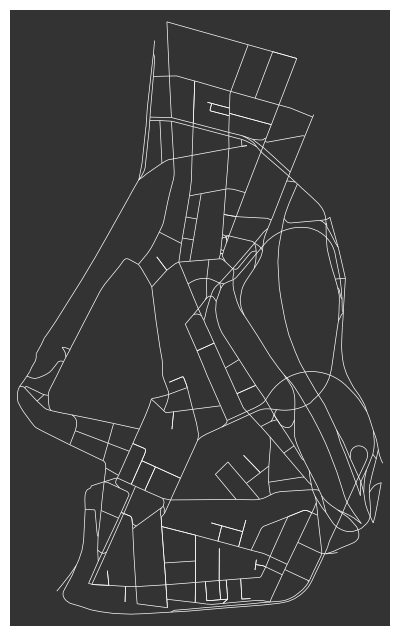

In [ ]:
# Em vez de baixar a cidade inteira, filtre por um raio (ex: 5km do centro) ou por tipo de via
# Usar 'network_type="drive"' já ajuda a remover vias de pedestres/ciclistas
# Define a área de interesse (exemplo: centro expandido de SP)
# Isso é muito mais leve do que baixar a cidade inteira
place_name = "Sé, São Paulo, Brazil"
grafo_viario = ox.graph_from_place(place_name, network_type='drive', simplify=True)

# Plotagem mais leve
fig, ax = ox.plot_graph(grafo_viario, node_size=0, edge_linewidth=0.5, edge_color='w', bgcolor='#333333')

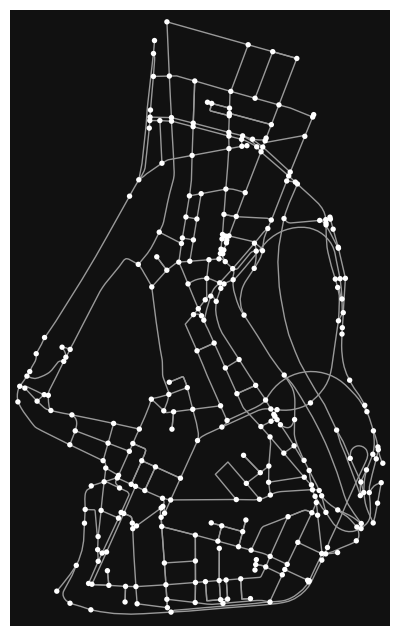

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# Visualização rápida para confirmar a ingestão
ox.plot_graph(grafo_viario)

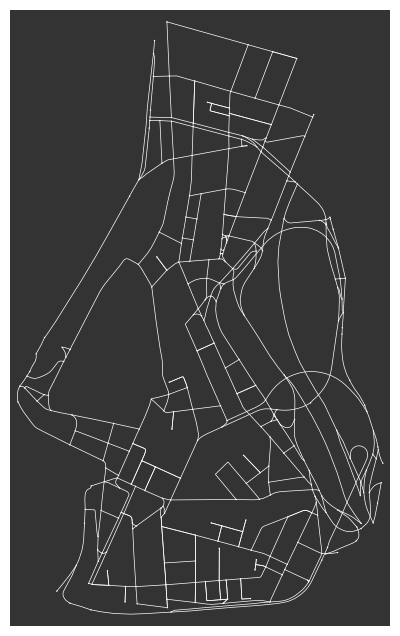

In [ ]:
# Ajustando a visualização para ficar mais "limpa" e profissional
fig, ax = ox.plot_graph(
    grafo_viario,
    node_size=1,            # Diminui o tamanho dos nós (pontos)
    edge_linewidth=0.5,     # Deixa as linhas das ruas mais finas
    edge_color='w',         # Cor branca para as ruas
    bgcolor='#333333',      # Fundo escuro (dá um aspecto moderno)
    show=True,
    close=False
)

In [ ]:
# Lista todas as variáveis que existem na memória agora
%whos

Variable                Type            Data/Info
-------------------------------------------------
F                       module          <module 'pyspark.sql.func<...>l/functions/__init__.py'>
SparkSession            type            <class 'pyspark.sql.session.SparkSession'>
ax                      Axes            Axes(0.27492,0.11;0.47516x0.77)
caminho_clima           str             /content/drive/MyDrive/pr<...>istica/data/southeast.csv
caminho_orders          str             /content/drive/MyDrive/pr<...>/olist_orders_dataset.csv
col                     str             PRESSAO ATMOSFERICA AO NI<...> DA ESTACAO, HORARIA (mB)
coluna                  str             order_estimated_delivery_date
coluna_chuva            str             PRECIPITAÇÃO TOTAL, HORÁRIO (mm)
coluna_data             str             Data
colunas_datas           list            n=5
colunas_numericas       list            n=2
df_clima                DataFrame       DataFrame[index: int, Dat<...>: double, heigh

In [ ]:
# Célula de Leitura Direta
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

# Caminho do seu arquivo
caminho_clima = "/content/drive/MyDrive/projeto_delivery_logistica/data/southeast.csv"

# Leitura direta com Spark (Otimiza memória e evita conflito de tipos)
df_sp = spark.read.csv(caminho_clima, header=True, inferSchema=True)

# Filtro imediato (reduz o tamanho antes de carregar na memória)
df_sp = df_sp.filter(df_sp['state'] == 'SP')

print("✅ Objeto 'df_sp' criado com sucesso diretamente via Spark.")
df_sp.printSchema()

✅ Objeto 'df_sp' criado com sucesso diretamente via Spark.
root
 |-- index: integer (nullable = true)
 |-- Data: date (nullable = true)
 |-- Hora: timestamp (nullable = true)
 |-- PRECIPITAÇÃO TOTAL, HORÁRIO (mm): double (nullable = true)
 |-- PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB): double (nullable = true)
 |-- PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB): double (nullable = true)
 |-- PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB): double (nullable = true)
 |-- RADIACAO GLOBAL (Kj/m²): integer (nullable = true)
 |-- TEMPERATURA DO AR - BULBO SECO, HORARIA (°C): double (nullable = true)
 |-- TEMPERATURA DO PONTO DE ORVALHO (°C): double (nullable = true)
 |-- TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C): double (nullable = true)
 |-- TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C): double (nullable = true)
 |-- TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C): double (nullable = true)
 |-- TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C): double (nullable = true)
 |-- UMID

#📊 7. Integração e Análise de Impacto Climático
Nesta etapa, utilizamos o PySpark para processar o histórico meteorológico de forma distribuída, garantindo eficiência no cruzamento de dados massivos. O objetivo é consolidar as informações climáticas (precipitação) com as métricas logísticas da Olist, permitindo a identificação de padrões onde eventos climáticos severos impactam diretamente o SLA de entrega.

In [ ]:
from pyspark.sql.functions import col, when

# 1. Realiza o join (o cruzamento dos dados)
df_pedidos_clima = df_pedidos.join(df_clima, ["data_pedido"], "left")

# 2. Limpeza Profissional (o "pulo do gato")
# Removemos linhas essenciais que faltam dados e preenchemos o resto
df_limpo = df_pedidos_clima.dropna(subset=["atraso_entrega_dias", "tempo_entrega_dias"]) \
                           .fillna({"media_chuva_mm": 0, "max_chuva_mm": 0}) \
                           .withColumn("media_chuva_mm", when(col("media_chuva_mm") < 0, 0).otherwise(col("media_chuva_mm")))

# 3. Registra a View com o nome que usaremos nas consultas SQL
df_limpo.createOrReplaceTempView("pedidos_clima_limpo")

# 4. Exibe uma amostra para você confirmar que não há mais NaN
df_limpo.select("data_pedido", "atraso_entrega_dias", "media_chuva_mm").show(5)

NameError: name 'df_pedidos' is not defined

In [ ]:
# --- Célula 7: Agregação e Integração Otimizada ---
from pyspark.sql import functions as F

# Nomes exatos conforme aparecem no seu printSchema()
col_data = "Data"
col_chuva = "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"

# 1. Agrupar no Spark (Processamento Distribuído)
df_clima_diario_spark = df_sp.groupBy(col_data).agg(
    F.avg(col_chuva).alias("media_chuva_mm"),
    F.max(col_chuva).alias("max_chuva_mm")
)

# 2. Trazer para o Pandas APENAS o resultado consolidado
df_clima_diario = df_clima_diario_spark.toPandas()

# 3. Preparar colunas para o merge
# Certifique-se de que os nomes das colunas de data sejam idênticos nos dois DataFrames
df_clima_diario['Data'] = pd.to_datetime(df_clima_diario['Data'])
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['Data'] = df_orders['order_purchase_timestamp'].dt.normalize()

# 4. Realizar o Merge
df_final = pd.merge(df_orders, df_clima_diario, on='Data', how='left')
df_final['media_chuva_mm'] = df_final['media_chuva_mm'].fillna(0)

print("✅ Integração concluída com sucesso!")
display(df_final.head())

## 8. Identificação de Variáveis e Correlação
Análise estatística para validar se o aumento da pluviosidade (chuva) impacta o 'atraso_entrega_dias'.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar colunas numéricas para correlação
colunas_analise = ['media_chuva_mm', 'atraso_entrega_dias', 'tempo_entrega_dias']
correlacao = df_final[colunas_analise].corr()

# Plotar Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação: Chuva vs Performance Logística")
plt.show()

In [ ]:
# Análise de Correlação

# 1. Calcular a matriz de correlação
# Queremos ver a relação entre 'media_chuva_mm' e 'atraso_entrega_dias'
correlacao = df_final[['media_chuva_mm', 'atraso_entrega_dias']].corr()

# 2. Plotar o mapa de calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação: Chuva vs Atraso na Entrega")
plt.show()

# 3. Plotar um gráfico de dispersão para visualizar a tendência
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_final, x='media_chuva_mm', y='atraso_entrega_dias', alpha=0.5)
plt.title("Dispersão: Intensidade da Chuva x Atraso")
plt.show()

#🔍 9. Análise Estruturada com Linguagem SQL
Nesta etapa, utilizamos a biblioteca pandasql para aplicar consultas SQL diretamente sobre o dataframe consolidado, extraindo métricas de negócio que validam nossas hipóteses

In [ ]:
# --- 🔍 9. Análise Estruturada com PySpark SQL ---

# 1. Converter o DataFrame do Pandas (df_final) de volta para o Spark
df_final_spark = spark.createDataFrame(df_final)

# 2. Registrar o DataFrame do Spark como uma View temporária
df_final_spark.createOrReplaceTempView("pedidos_clima")

# 3. Executar a consulta usando o motor nativo do Spark
query = """
SELECT
    CASE
        WHEN media_chuva_mm = 0 THEN 'Sem Chuva'
        WHEN media_chuva_mm BETWEEN 0.1 AND 10 THEN 'Chuva Leve'
        WHEN media_chuva_mm > 10 THEN 'Chuva Intensa'
        ELSE 'Indeterminado'
    END as categoria_chuva,
    COUNT(*) as total_pedidos,
    AVG(atraso_entrega_dias) as media_atraso_dias
FROM pedidos_clima
GROUP BY 1
ORDER BY media_atraso_dias DESC
"""

# 4. Executa a query e mostra o resultado
resultado = spark.sql(query)
resultado.show()

In [ ]:
# 1. Converter as colunas para tipo numérico e remover nulos
df_tratado = df_final_spark.withColumn("atraso_entrega_dias", df_final_spark["atraso_entrega_dias"].cast("double")) \
                           .withColumn("tempo_entrega_dias", df_final_spark["tempo_entrega_dias"].cast("double")) \
                           .na.fill(0, subset=["atraso_entrega_dias", "tempo_entrega_dias"])

# 2. Atualizar a View com os dados tratados
df_tratado.createOrReplaceTempView("pedidos_clima")

# 3. Agora rode a query de estatísticas novamente
query_stats = """
SELECT
    AVG(atraso_entrega_dias) as media_atraso,
    MAX(atraso_entrega_dias) as maior_atraso,
    AVG(tempo_entrega_dias) as media_tempo_entrega
FROM pedidos_clima
"""
spark.sql(query_stats).show()

In [ ]:
# Convertendo para Spark DataFrame e registrando a view
df_final_spark = spark.createDataFrame(df_final)
df_final_spark.createOrReplaceTempView("pedidos_clima")

# Query: Agrupa por mês para verificar a sazonalidade
query_sazonalidade = """
SELECT
    month(Data) as mes,            -- Extrai o mês da coluna de Data
    AVG(media_chuva_mm) as media_chuva_mes, -- Calcula a média de chuva no mês
    COUNT(order_id) as total_pedidos         -- Conta o total de pedidos realizados
FROM pedidos_clima
GROUP BY 1                         -- Agrupa pelo mês (primeira coluna)
ORDER BY 1                         -- Ordena de janeiro a dezembro
"""

spark.sql(query_sazonalidade).show()

In [ ]:
# Verifica as colunas disponíveis na View
spark.table("pedidos_clima").printSchema()

In [ ]:
# Analisa dias com chuva (media_chuva_mm > 0) e atraso (atraso_entrega_dias > 0)
query_chuva_atraso = """
SELECT
    Data,
    media_chuva_mm,
    atraso_entrega_dias
FROM pedidos_clima
WHERE media_chuva_mm > 0 AND atraso_entrega_dias > 0
ORDER BY atraso_entrega_dias DESC
LIMIT 10
"""
spark.sql(query_chuva_atraso).show()

In [ ]:
# Calcula a média e o tempo máximo de atraso encontrados na base
query_stats = """
SELECT
    AVG(atraso_entrega_dias) as media_atraso,
    MAX(atraso_entrega_dias) as maior_atraso,
    AVG(tempo_entrega_dias) as media_tempo_entrega
FROM pedidos_clima
"""
spark.sql(query_stats).show()